# IAC 2026 — Week 1b: Real Space-Weather / Physical-Drag Upgrade

**Paper:** *Hybrid AI-Augmented Framework for High-Fidelity Tracking of Non-Cooperative Objects*  
**Paper ID:** IAC-26,A6,9,8,x109530

## Why this notebook exists

Week 1 successfully established:

- a frozen current Starlink SupGP orbital snapshot;
- 30 diverse Starlink orbital initial conditions;
- 24-hour propagation;
- observation blackouts;
- a corrected state-dependent Cartesian EKF.

However, the Week-1 disturbance term was a deliberately synthetic drag-like forcing and produced overly large 24-hour trajectory divergence.

This notebook replaces that synthetic forcing with a more defensible physical chain:

**historically observed F10.7 + Ap → NRLMSISE-00 density → physical atmospheric drag**

The historical space-weather data are retrieved through **PyMSIS/CelesTrak**. PyMSIS uses the observed/derived F10.7 and Ap values required by MSIS and supports storm-time Ap history.

### Important scientific distinction

This is a **historical space-weather replay experiment**, not a reconstruction of the exact historical Starlink trajectories.

The orbital initial conditions come from the frozen 2026 Starlink snapshot collected in Week 1, while the thermospheric forcing is replayed from observed historical intervals (the February 2022 Starlink-storm period). This creates representative Starlink orbits exposed to real recorded space-weather conditions.

The spacecraft aerodynamic response is still uncertain. For the Week-1b calibration we use representative literature values:

- drag coefficient: `Cd = 2.2`
- area-to-mass ratio: `A/m = 0.02 m²/kg`

Those parameters should be treated as representative assumptions rather than exact properties of every Starlink spacecraft.

## What Week 1b does

1. Upload and reuse the exact `IAC2026_FINAL_WEEK1_bundle.zip`.
2. Correct the 18/6/6 object split so the held-out test set spans the major inclination shells.
3. Download historical F10.7/Ap data.
4. Objectively choose quiet / moderate / storm 24-hour windows from the 2022 Starlink-event period.
5. Use NRLMSISE-00 to compute density along representative Starlink orbital tracks.
6. Propagate two-body+J2+physical-drag truth trajectories.
7. Compare real-weather drag response across multiple TRAIN objects.
8. Re-tune EKF process noise using TRAIN/VALIDATION objects only.
9. Keep all six TEST objects completely untouched.
10. Save a Week-1b reproducibility bundle.

**There is no GRU training in this notebook.**

In [ ]:
# S0 — Colab dependencies

!pip -q install "sgp4>=2.25" "pymsis>=0.12.0" "astropy>=6.0" scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.1/218.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.1 MB/s eta 0:00:00


In [ ]:
# S1 — Imports and folders

import json
import math
import shutil
import zipfile
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2
from sklearn.preprocessing import StandardScaler

from sgp4.api import Satrec, SGP4_ERRORS
from sgp4 import omm

import pymsis
from pymsis.utils import download_f107_ap, get_f107_ap

import astropy.units as u
from astropy.time import Time, TimeDelta
from astropy.coordinates import (
    TEME,
    ITRS,
    EarthLocation,
    CartesianRepresentation,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 20260824
np.random.seed(SEED)

ROOT_DIR = Path("/content/IAC2026_FINAL_WEEK1B")
SOURCE_DIR = ROOT_DIR / "week1_source"
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "outputs"

for p in [ROOT_DIR, SOURCE_DIR, DATA_DIR, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 11

print("✅ Week 1b environment initialized")
print("   root:", ROOT_DIR)

✅ Week 1b environment initialized
   root: /content/IAC2026_FINAL_WEEK1B


# 1 — Load the exact Week-1 frozen snapshot

Do **not** redownload the Starlink orbital catalog here.

Upload the exact ZIP produced by the successful Week-1 run:

`IAC2026_FINAL_WEEK1_bundle.zip`

This preserves the orbital snapshot and the original 30-object cohort exactly.

In [ ]:
# A0 — Locate or upload Week-1 bundle

EXPECTED_ZIP = Path(
    "/content/IAC2026_FINAL_WEEK1_bundle.zip"
)

if not EXPECTED_ZIP.exists():

    print(
        "Please upload IAC2026_FINAL_WEEK1_bundle.zip"
    )

    from google.colab import files

    uploaded = files.upload()

    zip_names = [
        name
        for name in uploaded
        if name.lower().endswith(".zip")
    ]

    if len(zip_names) != 1:
        raise RuntimeError(
            "Please upload exactly one Week-1 ZIP."
        )

    uploaded_name = zip_names[0]

    uploaded_path = Path(
        "/content"
    ) / uploaded_name

    if uploaded_path != EXPECTED_ZIP:
        shutil.copy2(
            uploaded_path,
            EXPECTED_ZIP,
        )

with zipfile.ZipFile(
    EXPECTED_ZIP,
    "r",
) as z:
    z.extractall(
        SOURCE_DIR
    )

print("✅ Week-1 bundle extracted")
print("   source:", EXPECTED_ZIP)
print("   extracted:", SOURCE_DIR)

Please upload IAC2026_FINAL_WEEK1_bundle.zip


Saving IAC2026_FINAL_WEEK1_bundle.zip to IAC2026_FINAL_WEEK1_bundle.zip
✅ Week-1 bundle extracted
   source: /content/IAC2026_FINAL_WEEK1_bundle.zip
   extracted: /content/IAC2026_FINAL_WEEK1B/week1_source


In [ ]:
# A1 — Find Week-1 cohort and frozen Starlink OMM snapshot

def find_unique_file(
    root,
    filename,
):
    matches = list(
        Path(root).rglob(filename)
    )

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected exactly one {filename}; "
            f"found {len(matches)}"
        )

    return matches[0]


WEEK1_COHORT_PATH = find_unique_file(
    SOURCE_DIR,
    "starlink_30_object_cohort.csv",
)

WEEK1_SNAPSHOT_PATH = find_unique_file(
    SOURCE_DIR,
    "starlink_supgp_snapshot.json",
)

week1_cohort = pd.read_csv(
    WEEK1_COHORT_PATH
)

with open(
    WEEK1_SNAPSHOT_PATH,
    "r",
) as f:
    starlink_records = json.load(f)

assert len(week1_cohort) == 30
assert week1_cohort["NORAD_CAT_ID"].nunique() == 30

print("✅ Frozen Week-1 inputs loaded")
print("   cohort objects:", len(week1_cohort))
print("   snapshot records:", len(starlink_records))
print("   cohort:", WEEK1_COHORT_PATH)
print("   snapshot:", WEEK1_SNAPSHOT_PATH)

✅ Frozen Week-1 inputs loaded
   cohort objects: 30
   snapshot records: 11051
   cohort: /content/IAC2026_FINAL_WEEK1B/week1_source/data/starlink_30_object_cohort.csv
   snapshot: /content/IAC2026_FINAL_WEEK1B/week1_source/data/starlink_supgp_snapshot.json


# 2 — Correct and permanently freeze the object-level split

The Week-1 cohort itself is diverse, but the original repeating split accidentally placed no ~70° or ~97° object in the final TEST set.

We now stratify by the four inclination populations present in this frozen 30-object cohort.

Target allocation:

| Shell | TRAIN | VALIDATION | TEST |
|---|---:|---:|---:|
| ~43° | 7 | 3 | 2 |
| ~53° | 5 | 1 | 2 |
| ~70° | 1 | 0 | 1 |
| ~97° | 5 | 2 | 1 |
| **Total** | **18** | **6** | **6** |

Within each shell, test and validation members are selected deterministically for diversity in RAAN, altitude, eccentricity, and BSTAR.

**This split is frozen before any learned model is trained.**

In [ ]:
# A2 — Stratified diverse split

def inclination_shell(inc_deg):
    inc_deg = float(inc_deg)

    if inc_deg < 50:
        return "43deg"
    elif inc_deg < 60:
        return "53deg"
    elif inc_deg < 80:
        return "70deg"
    else:
        return "97deg"


cohort_df = week1_cohort.copy()

cohort_df["SHELL"] = (
    cohort_df["INCLINATION"]
    .map(inclination_shell)
)


ALLOCATION = {
    "43deg": {
        "TEST": 2,
        "VALIDATION": 3,
    },
    "53deg": {
        "TEST": 2,
        "VALIDATION": 1,
    },
    "70deg": {
        "TEST": 1,
        "VALIDATION": 0,
    },
    "97deg": {
        "TEST": 1,
        "VALIDATION": 2,
    },
}


def farthest_select(
    group,
    n_select,
    excluded_indices=None,
):

    if n_select == 0:
        return []

    if excluded_indices is None:
        excluded_indices = []

    g = group.loc[
        ~group.index.isin(
            excluded_indices
        )
    ].copy()

    raan = np.deg2rad(
        g["RA_OF_ASC_NODE"]
        .to_numpy()
    )

    X = np.column_stack([
        np.sin(raan),
        np.cos(raan),
        g["APPROX_ALT_KM"].to_numpy(),
        g["ECCENTRICITY"].to_numpy() * 1e4,
        np.log10(
            np.abs(
                g["BSTAR"].to_numpy()
            )
            + 1e-12
        ),
    ])

    X = (
        X - X.mean(axis=0)
    ) / (
        X.std(axis=0)
        + 1e-12
    )

    source_indices = list(
        g.index
    )

    start = int(
        np.argmax(
            np.linalg.norm(
                X,
                axis=1,
            )
        )
    )

    selected_local = [
        start
    ]

    min_dist = np.linalg.norm(
        X - X[start],
        axis=1,
    )

    while (
        len(selected_local)
        < n_select
    ):

        min_dist[
            selected_local
        ] = -np.inf

        nxt = int(
            np.argmax(
                min_dist
            )
        )

        selected_local.append(
            nxt
        )

        d = np.linalg.norm(
            X - X[nxt],
            axis=1,
        )

        min_dist = np.minimum(
            min_dist,
            d,
        )

    return [
        source_indices[i]
        for i in selected_local
    ]


cohort_df["SPLIT"] = "TRAIN"

for shell, alloc in ALLOCATION.items():

    group = cohort_df[
        cohort_df["SHELL"]
        == shell
    ]

    test_idx = farthest_select(
        group,
        alloc["TEST"],
    )

    val_idx = farthest_select(
        group,
        alloc["VALIDATION"],
        excluded_indices=test_idx,
    )

    cohort_df.loc[
        test_idx,
        "SPLIT"
    ] = "TEST"

    cohort_df.loc[
        val_idx,
        "SPLIT"
    ] = "VALIDATION"


assert (
    cohort_df["SPLIT"]
    == "TRAIN"
).sum() == 18

assert (
    cohort_df["SPLIT"]
    == "VALIDATION"
).sum() == 6

assert (
    cohort_df["SPLIT"]
    == "TEST"
).sum() == 6


split_counts = (
    cohort_df
    .groupby(
        ["SHELL", "SPLIT"]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

display(
    split_counts
)

display(
    cohort_df[
        [
            "OBJECT_NAME",
            "NORAD_CAT_ID",
            "INCLINATION",
            "RA_OF_ASC_NODE",
            "APPROX_ALT_KM",
            "SHELL",
            "SPLIT",
        ]
    ]
)

CORRECTED_COHORT_PATH = (
    DATA_DIR
    / "starlink_30_object_cohort_WEEK1B.csv"
)

cohort_df.to_csv(
    CORRECTED_COHORT_PATH,
    index=False,
)

print("✅ Corrected split frozen")
print("   saved:", CORRECTED_COHORT_PATH)

SPLIT,TEST,TRAIN,VALIDATION
SHELL,,,
43deg,2,7,3
53deg,2,5,1
70deg,1,1,0
97deg,1,5,2


,OBJECT_NAME,NORAD_CAT_ID,INCLINATION,RA_OF_ASC_NODE,APPROX_ALT_KM,SHELL,SPLIT
0,STARLINK-32664,62204,42.9884,5.6113,347.969902,43deg,TRAIN
1,STARLINK-4446,53505,97.6029,14.6025,291.626802,97deg,TRAIN
2,STARLINK-34227,64178,53.1587,33.9972,474.442521,53deg,TRAIN
3,STARLINK-1676,46556,53.0238,35.6209,260.150953,53deg,TEST
4,STARLINK-30053,56700,43.0014,46.1356,483.032546,43deg,VALIDATION
5,STARLINK-6085,57115,42.9968,53.9184,505.934823,43deg,TRAIN
6,STARLINK-38033,69739,97.2850,75.3518,465.500757,97deg,VALIDATION
7,STARLINK-37962,69693,97.2849,83.2053,465.537772,97deg,TRAIN
8,STARLINK-34725,64843,97.2850,86.9436,465.619591,97deg,TRAIN
9,STARLINK-32955,63117,42.9806,96.1565,303.218018,43deg,TEST


✅ Corrected split frozen
   saved: /content/IAC2026_FINAL_WEEK1B/data/starlink_30_object_cohort_WEEK1B.csv


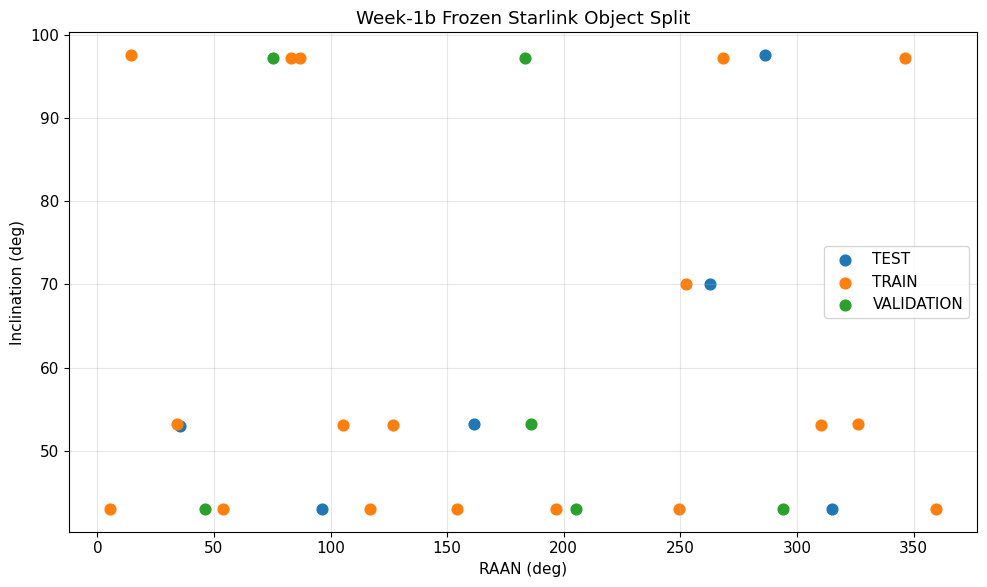

✅ TEST set includes: ['43deg', '53deg', '70deg', '97deg']


In [ ]:
# A3 — Verify TEST set spans all four inclination shells

test_shells = set(
    cohort_df.loc[
        cohort_df["SPLIT"]
        == "TEST",
        "SHELL",
    ]
)

expected_shells = {
    "43deg",
    "53deg",
    "70deg",
    "97deg",
}

assert (
    test_shells
    == expected_shells
)

plt.figure(
    figsize=(10, 6)
)

for split_name, group in (
    cohort_df.groupby("SPLIT")
):

    plt.scatter(
        group["RA_OF_ASC_NODE"],
        group["INCLINATION"],
        s=60,
        label=split_name,
    )

plt.xlabel("RAAN (deg)")
plt.ylabel("Inclination (deg)")
plt.title(
    "Week-1b Frozen Starlink Object Split"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

SPLIT_PLOT = (
    OUTPUT_DIR
    / "week1b_corrected_object_split.png"
)

plt.savefig(
    SPLIT_PLOT,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "✅ TEST set includes:",
    sorted(test_shells),
)

In [ ]:
# A4 — Reinitialize Satrec objects from frozen OMM snapshot

latest_by_norad = {}

for rec in starlink_records:

    try:
        norad = int(
            rec["NORAD_CAT_ID"]
        )

        epoch = pd.Timestamp(
            rec["EPOCH"]
        )

    except Exception:
        continue

    if (
        norad not in latest_by_norad
        or epoch
        > pd.Timestamp(
            latest_by_norad[norad][
                "EPOCH"
            ]
        )
    ):
        latest_by_norad[
            norad
        ] = rec


satrec_by_norad = {}

for norad in (
    cohort_df[
        "NORAD_CAT_ID"
    ]
    .astype(int)
):

    rec = latest_by_norad[
        norad
    ]

    sat = Satrec()

    omm.initialize(
        sat,
        rec,
    )

    satrec_by_norad[
        norad
    ] = sat


print(
    "✅ Reinitialized",
    len(satrec_by_norad),
    "frozen cohort objects",
)

✅ Reinitialized 30 frozen cohort objects


# 3 — Retrieve REAL historical solar / geomagnetic forcing

We use the historical interval surrounding the **February 2022 Starlink storm event**.

Instead of manually inventing quiet/moderate/storm curves, the notebook:

1. retrieves historical F10.7 and Ap;
2. examines candidate 24-hour windows from 2022-01-25 through 2022-02-08;
3. chooses:
   - the day with the lowest mean 3-hour Ap as **QUIET**;
   - the day closest to the median as **MODERATE**;
   - the day with the highest mean 3-hour Ap as **STORM**.

The selection criterion is therefore defined before orbit-performance results are calculated.

In [ ]:
# B0 — Download/update historical F10.7 / Ap file used by PyMSIS

try:

    download_f107_ap()

    print(
        "✅ Historical space-weather database available"
    )

except Exception as exc:

    print(
        "⚠️ PyMSIS space-weather download failed"
    )

    print(
        repr(exc)
    )

    raise RuntimeError(
        "Colab needs internet access for the initial "
        "historical space-weather download."
    )

/usr/local/lib/python3.13/dist-packages/pymsis/utils.py:45: UserWarning: Downloading ap and F10.7 data from https://celestrak.org/SpaceData/SW-All.csv
  warnings.warn(f"Downloading ap and F10.7 data from {_F107_AP_URL}")


✅ Historical space-weather database available


In [ ]:
# B1 — Objectively select real quiet/moderate/storm 24-h windows

SCAN_START = np.datetime64(
    "2022-01-25T00:00"
)

SCAN_END = np.datetime64(
    "2022-02-09T00:00"
)

scan_dates = np.arange(
    SCAN_START,
    SCAN_END,
    np.timedelta64(
        3,
        "h",
    ),
)

scan_f107, scan_f107a, scan_aps = (
    get_f107_ap(
        scan_dates
    )
)

scan_df = pd.DataFrame({
    "datetime": pd.to_datetime(
        scan_dates
    ),
    "f107_previous_day": scan_f107,
    "f107_81day": scan_f107a,
    "daily_Ap": scan_aps[:, 0],
    "current_3h_ap": scan_aps[:, 1],
})

scan_df["date"] = (
    scan_df["datetime"]
    .dt.floor("D")
)

daily_activity = (
    scan_df
    .groupby("date")
    .agg(
        mean_3h_ap=(
            "current_3h_ap",
            "mean",
        ),
        max_3h_ap=(
            "current_3h_ap",
            "max",
        ),
        mean_daily_Ap=(
            "daily_Ap",
            "mean",
        ),
        mean_f107=(
            "f107_previous_day",
            "mean",
        ),
    )
    .reset_index()
)


quiet_row = (
    daily_activity
    .sort_values(
        [
            "mean_3h_ap",
            "max_3h_ap",
        ]
    )
    .iloc[0]
)

storm_row = (
    daily_activity
    .sort_values(
        [
            "mean_3h_ap",
            "max_3h_ap",
        ],
        ascending=False,
    )
    .iloc[0]
)

remaining = daily_activity[
    ~daily_activity["date"].isin(
        [
            quiet_row["date"],
            storm_row["date"],
        ]
    )
].copy()

median_activity = (
    remaining[
        "mean_3h_ap"
    ]
    .median()
)

moderate_idx = (
    (
        remaining[
            "mean_3h_ap"
        ]
        - median_activity
    )
    .abs()
    .idxmin()
)

moderate_row = (
    remaining.loc[
        moderate_idx
    ]
)


REAL_EVENT_DAYS = {
    "quiet": np.datetime64(
        quiet_row["date"],
        "D",
    ),
    "moderate": np.datetime64(
        moderate_row["date"],
        "D",
    ),
    "storm": np.datetime64(
        storm_row["date"],
        "D",
    ),
}


print(
    "✅ Real 24-h forcing windows selected"
)

for label, day in (
    REAL_EVENT_DAYS.items()
):
    row = daily_activity[
        daily_activity["date"]
        == pd.Timestamp(day)
    ].iloc[0]

    print(
        f"   {label:8s}: {day} | "
        f"mean 3h ap={row['mean_3h_ap']:.2f} | "
        f"max 3h ap={row['max_3h_ap']:.1f} | "
        f"F10.7={row['mean_f107']:.1f}"
    )

display(
    daily_activity
)

ACTIVITY_SCAN_PATH = (
    DATA_DIR
    / "real_space_weather_daily_activity_scan.csv"
)

daily_activity.to_csv(
    ACTIVITY_SCAN_PATH,
    index=False,
)

✅ Real 24-h forcing windows selected
   quiet   : 2022-02-08 | mean 3h ap=4.12 | max 3h ap=7.0 | F10.7=127.2
   moderate: 2022-01-30 | mean 3h ap=10.25 | max 3h ap=15.0 | F10.7=125.3
   storm   : 2022-02-04 | mean 3h ap=32.00 | max 3h ap=56.0 | F10.7=126.5


,date,mean_3h_ap,max_3h_ap,mean_daily_Ap,mean_f107
0,2022-01-25,13.500,18.0,14.0,95.2
1,2022-01-26,9.750,15.0,10.0,100.9
2,2022-01-27,6.500,15.0,6.0,101.8
3,2022-01-28,7.125,22.0,7.0,107.1
4,2022-01-29,14.500,27.0,14.0,113.4
5,2022-01-30,10.250,15.0,10.0,125.3
6,2022-01-31,9.000,15.0,9.0,129.6
7,2022-02-01,5.750,18.0,6.0,129.5
8,2022-02-02,10.375,27.0,10.0,128.6
9,2022-02-03,26.500,56.0,26.0,128.2


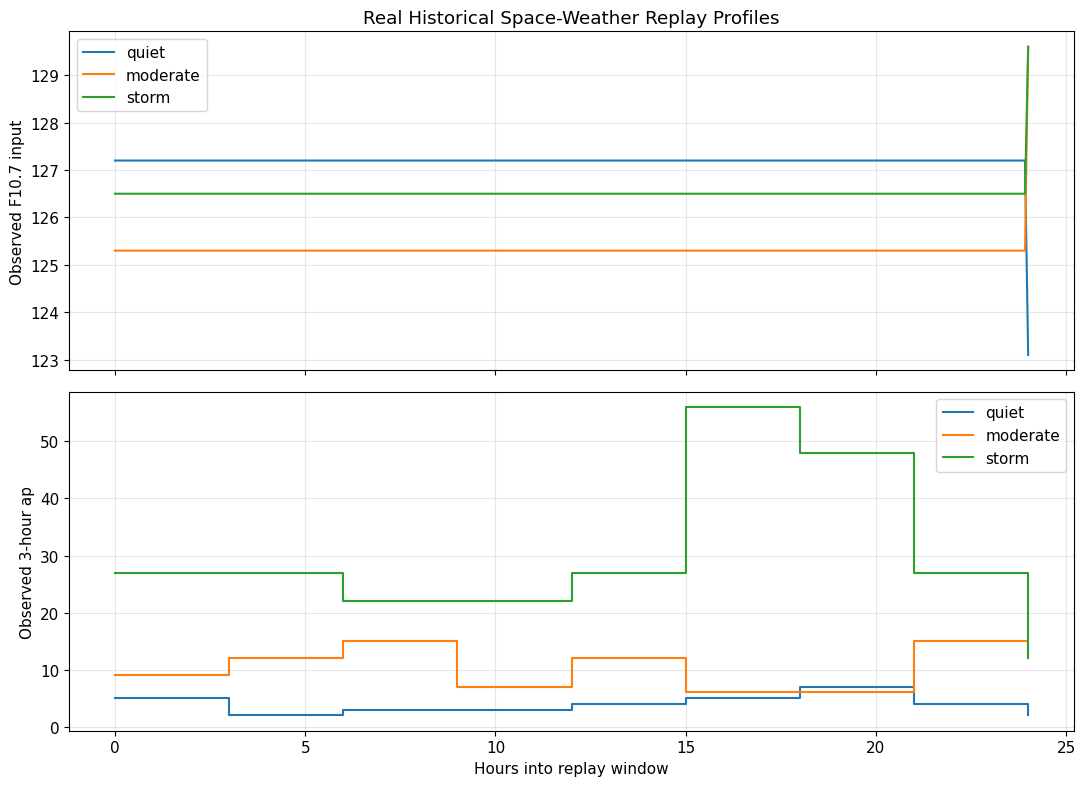

✅ Saved: /content/IAC2026_FINAL_WEEK1B/outputs/real_historical_F107_Ap_profiles.png


In [ ]:
# B2 — Build 5-minute real forcing profiles for selected days

DENSITY_STEP_MIN = 5

def build_real_weather_profile(
    day,
):

    start = np.datetime64(
        day,
        "m",
    )

    dates = np.arange(
        start,
        start
        + np.timedelta64(
            24*60 + DENSITY_STEP_MIN,
            "m",
        ),
        np.timedelta64(
            DENSITY_STEP_MIN,
            "m",
        ),
    )

    f107, f107a, aps = (
        get_f107_ap(
            dates
        )
    )

    return {
        "dates": dates,
        "f107": np.asarray(
            f107,
            dtype=float,
        ),
        "f107a": np.asarray(
            f107a,
            dtype=float,
        ),
        "aps": np.asarray(
            aps,
            dtype=float,
        ),
        "current_ap": np.asarray(
            aps[:, 1],
            dtype=float,
        ),
        "daily_ap": np.asarray(
            aps[:, 0],
            dtype=float,
        ),
        "time_hr": (
            np.arange(
                len(dates)
            )
            * DENSITY_STEP_MIN
            / 60.0
        ),
    }


real_weather_profiles = {
    label: build_real_weather_profile(
        day
    )
    for label, day
    in REAL_EVENT_DAYS.items()
}


fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True,
)

for label, prof in (
    real_weather_profiles.items()
):

    axes[0].plot(
        prof["time_hr"],
        prof["f107"],
        label=label,
    )

    axes[1].step(
        prof["time_hr"],
        prof["current_ap"],
        where="post",
        label=label,
    )


axes[0].set_ylabel(
    "Observed F10.7 input"
)

axes[0].set_title(
    "Real Historical Space-Weather Replay Profiles"
)

axes[0].grid(
    alpha=0.3
)

axes[0].legend()


axes[1].set_xlabel(
    "Hours into replay window"
)

axes[1].set_ylabel(
    "Observed 3-hour ap"
)

axes[1].grid(
    alpha=0.3
)

axes[1].legend()

plt.tight_layout()

REAL_WEATHER_PLOT = (
    OUTPUT_DIR
    / "real_historical_F107_Ap_profiles.png"
)

plt.savefig(
    REAL_WEATHER_PLOT,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "✅ Saved:",
    REAL_WEATHER_PLOT,
)

# 4 — Orbit helpers and NRLMSISE-00 fly-through density

For each representative Starlink object:

1. propagate its frozen SupGP state over 24 h with SGP4;
2. convert the SGP4 TEME positions to geodetic latitude/longitude/altitude;
3. replay those geodetic positions through the selected historical dates;
4. ask NRLMSISE-00 for the total atmospheric mass density using the **real F10.7/Ap histories**.

This is much more physically meaningful than multiplying an arbitrary synthetic disturbance scalar.

In [ ]:
# C0 — Constants and SGP4 helpers

MU_EARTH = 398600.4418   # km^3/s^2
R_EARTH = 6378.1363      # km
J2 = 1.08262668e-3

OMEGA_EARTH = np.array([
    0.0,
    0.0,
    7.2921159e-5,
])  # rad/s

DYN_DT = 60.0
DYN_HOURS = 24

DYN_N_STEPS = int(
    DYN_HOURS
    * 3600
    / DYN_DT
) + 1

DYN_TIME_HR = (
    np.arange(
        DYN_N_STEPS
    )
    * DYN_DT
    / 3600.0
)


def sgp4_state_at_offset(
    sat,
    dt_seconds,
):

    jd_total = (
        sat.jdsatepoch
        + sat.jdsatepochF
        + float(dt_seconds)
        / 86400.0
    )

    jd = math.floor(
        jd_total
    )

    fr = (
        jd_total
        - jd
    )

    err, r, v = sat.sgp4(
        jd,
        fr,
    )

    if err != 0:

        raise RuntimeError(
            f"SGP4 error {err}: "
            f"{SGP4_ERRORS.get(err, 'unknown')}"
        )

    return (
        np.asarray(
            r,
            dtype=float,
        ),
        np.asarray(
            v,
            dtype=float,
        ),
    )


def sgp4_series(
    sat,
    step_seconds,
    hours=24,
):

    n = int(
        hours
        * 3600
        / step_seconds
    ) + 1

    states = np.zeros(
        (n, 6)
    )

    for k in range(n):

        r, v = (
            sgp4_state_at_offset(
                sat,
                k*step_seconds,
            )
        )

        states[k] = np.concatenate(
            [r, v]
        )

    return states


print(
    "✅ Orbit helpers defined"
)

✅ Orbit helpers defined


In [ ]:
# C1 — Select representative TRAIN objects for Week-1b calibration
#
# One object per inclination shell, chosen near the shell's median altitude.
# No TEST object is used.

def choose_shell_representative(
    split,
    shell,
):

    group = cohort_df[
        (
            cohort_df["SPLIT"]
            == split
        )
        &
        (
            cohort_df["SHELL"]
            == shell
        )
    ].copy()

    if len(group) == 0:
        return None

    median_alt = (
        group[
            "APPROX_ALT_KM"
        ]
        .median()
    )

    idx = (
        (
            group[
                "APPROX_ALT_KM"
            ]
            - median_alt
        )
        .abs()
        .idxmin()
    )

    return group.loc[
        idx
    ]


TRAIN_REPRESENTATIVES = []

for shell in [
    "43deg",
    "53deg",
    "70deg",
    "97deg",
]:

    row = (
        choose_shell_representative(
            "TRAIN",
            shell,
        )
    )

    if row is not None:

        TRAIN_REPRESENTATIVES.append(
            row
        )


VALIDATION_REPRESENTATIVES = []

for shell in [
    "43deg",
    "53deg",
    "97deg",
]:

    row = (
        choose_shell_representative(
            "VALIDATION",
            shell,
        )
    )

    if row is not None:

        VALIDATION_REPRESENTATIVES.append(
            row
        )


train_rep_df = pd.DataFrame(
    TRAIN_REPRESENTATIVES
)

val_rep_df = pd.DataFrame(
    VALIDATION_REPRESENTATIVES
)


print(
    "TRAIN calibration objects:"
)

display(
    train_rep_df[
        [
            "OBJECT_NAME",
            "NORAD_CAT_ID",
            "SHELL",
            "APPROX_ALT_KM",
        ]
    ]
)


print(
    "VALIDATION calibration objects:"
)

display(
    val_rep_df[
        [
            "OBJECT_NAME",
            "NORAD_CAT_ID",
            "SHELL",
            "APPROX_ALT_KM",
        ]
    ]
)


assert not (
    set(
        train_rep_df[
            "NORAD_CAT_ID"
        ]
    )
    &
    set(
        cohort_df.loc[
            cohort_df["SPLIT"]
            == "TEST",
            "NORAD_CAT_ID",
        ]
    )
)

assert not (
    set(
        val_rep_df[
            "NORAD_CAT_ID"
        ]
    )
    &
    set(
        cohort_df.loc[
            cohort_df["SPLIT"]
            == "TEST",
            "NORAD_CAT_ID",
        ]
    )
)

print(
    "✅ No TEST object enters calibration"
)

TRAIN calibration objects:


,OBJECT_NAME,NORAD_CAT_ID,SHELL,APPROX_ALT_KM
13,STARLINK-5049,57246,43deg,483.046484
12,STARLINK-1193,45100,53deg,340.459245
20,STARLINK-34312,64711,70deg,572.020898
28,STARLINK-36698,67709,97deg,465.521554


VALIDATION calibration objects:


,OBJECT_NAME,NORAD_CAT_ID,SHELL,APPROX_ALT_KM
18,STARLINK-30327,57707,43deg,405.009636
16,STARLINK-2446,47844,53deg,454.588200
6,STARLINK-38033,69739,97deg,465.500757


✅ No TEST object enters calibration


In [ ]:
# C2 — Convert SGP4 TEME track to geodetic coordinates

def teme_track_to_geodetic(
    sat,
    states,
    step_seconds,
):

    n = len(
        states
    )

    offsets = (
        np.arange(n)
        * step_seconds
    )

    epoch_jd = (
        sat.jdsatepoch
        + sat.jdsatepochF
    )

    obstime = (
        Time(
            epoch_jd,
            format="jd",
            scale="utc",
        )
        +
        TimeDelta(
            offsets
            * u.s
        )
    )

    rep = CartesianRepresentation(
        x=states[:, 0] * u.km,
        y=states[:, 1] * u.km,
        z=states[:, 2] * u.km,
    )

    teme = TEME(
        rep,
        obstime=obstime,
    )

    itrs = teme.transform_to(
        ITRS(
            obstime=obstime
        )
    )

    xyz = itrs.cartesian

    location = (
        EarthLocation
        .from_geocentric(
            xyz.x,
            xyz.y,
            xyz.z,
        )
    )

    return {
        "lon_deg": (
            location.lon
            .to_value(u.deg)
        ),
        "lat_deg": (
            location.lat
            .to_value(u.deg)
        ),
        "alt_km": (
            location.height
            .to_value(u.km)
        ),
    }


print(
    "✅ TEME → geodetic helper defined"
)

✅ TEME → geodetic helper defined


In [ ]:
# C3 — NRLMSISE-00 density along a representative orbit
#
# The orbit geometry is from the frozen Starlink snapshot.
# Historical dates supply real F10.7 / Ap forcing.

def real_density_profile_for_object(
    row,
    weather_label,
):

    norad = int(
        row["NORAD_CAT_ID"]
    )

    sat = satrec_by_norad[
        norad
    ]

    step_seconds = (
        DENSITY_STEP_MIN
        * 60.0
    )

    track = sgp4_series(
        sat,
        step_seconds,
        hours=DYN_HOURS,
    )

    geo = (
        teme_track_to_geodetic(
            sat,
            track,
            step_seconds,
        )
    )

    weather = (
        real_weather_profiles[
            weather_label
        ]
    )

    dates = weather[
        "dates"
    ]

    if (
        len(dates)
        != len(track)
    ):
        raise RuntimeError(
            "Density timeline and orbital track length mismatch."
        )

    f107 = weather[
        "f107"
    ]

    f107a = weather[
        "f107a"
    ]

    aps = weather[
        "aps"
    ]

    msis_output = (
        pymsis.calculate(
            dates,
            geo["lon_deg"],
            geo["lat_deg"],
            geo["alt_km"],
            f107s=f107,
            f107as=f107a,
            aps=aps,
            geomagnetic_activity=-1,
            version=0,
        )
    )

    rho = np.asarray(
        msis_output[
            ...,
            pymsis.Variable.MASS_DENSITY,
        ]
    ).squeeze()

    rho = np.asarray(
        rho,
        dtype=float,
    )

    if (
        len(rho)
        != len(track)
        or not np.all(
            np.isfinite(rho)
        )
        or np.any(
            rho <= 0
        )
    ):
        raise RuntimeError(
            "Invalid MSIS density output."
        )

    return {
        "norad": norad,
        "name": str(
            row["OBJECT_NAME"]
        ),
        "shell": str(
            row["SHELL"]
        ),
        "weather_label": (
            weather_label
        ),
        "time_s": (
            np.arange(
                len(rho)
            )
            * step_seconds
        ),
        "time_hr": (
            np.arange(
                len(rho)
            )
            * step_seconds
            / 3600.0
        ),
        "rho_kg_m3": rho,
        "lon_deg": geo[
            "lon_deg"
        ],
        "lat_deg": geo[
            "lat_deg"
        ],
        "alt_km": geo[
            "alt_km"
        ],
        "sgp4_track": track,
    }


print(
    "✅ Real-density fly-through function defined"
)

✅ Real-density fly-through function defined


In [ ]:
# C4 — Build real density profiles for TRAIN calibration objects

density_profiles = {}

for _, row in (
    train_rep_df.iterrows()
):

    norad = int(
        row["NORAD_CAT_ID"]
    )

    for weather_label in [
        "quiet",
        "moderate",
        "storm",
    ]:

        print(
            f"MSIS density: "
            f"{row['OBJECT_NAME']} | "
            f"{weather_label}"
        )

        density_profiles[
            (
                norad,
                weather_label,
            )
        ] = (
            real_density_profile_for_object(
                row,
                weather_label,
            )
        )


print(
    "✅ Real NRLMSISE-00 density profiles generated"
)

MSIS density: STARLINK-5049 | quiet
MSIS density: STARLINK-5049 | moderate
MSIS density: STARLINK-5049 | storm
MSIS density: STARLINK-1193 | quiet
MSIS density: STARLINK-1193 | moderate
MSIS density: STARLINK-1193 | storm
MSIS density: STARLINK-34312 | quiet
MSIS density: STARLINK-34312 | moderate
MSIS density: STARLINK-34312 | storm
MSIS density: STARLINK-36698 | quiet
MSIS density: STARLINK-36698 | moderate
MSIS density: STARLINK-36698 | storm
✅ Real NRLMSISE-00 density profiles generated


,norad,name,shell,weather,median_density_kg_m3,p95_density_kg_m3,max_density_kg_m3,min_alt_km,max_alt_km
0,57246,STARLINK-5049,43deg,quiet,3.774539e-13,7.304910e-13,7.836160e-13,482.044394,495.926962
1,57246,STARLINK-5049,43deg,moderate,4.288089e-13,7.821652e-13,8.068182e-13,482.044394,495.926962
2,57246,STARLINK-5049,43deg,storm,5.253631e-13,9.523282e-13,1.024221e-12,482.044394,495.926962
3,45100,STARLINK-1193,53deg,quiet,6.177499e-12,7.579475e-12,7.864782e-12,337.307632,360.141886
4,45100,STARLINK-1193,53deg,moderate,6.661866e-12,7.962086e-12,8.113667e-12,337.307632,360.141886
5,45100,STARLINK-1193,53deg,storm,7.728950e-12,9.345578e-12,9.565821e-12,337.307632,360.141886
6,64711,STARLINK-34312,70deg,quiet,7.952590e-14,2.073445e-13,2.150596e-13,573.857543,594.748043
7,64711,STARLINK-34312,70deg,moderate,9.329083e-14,2.268375e-13,2.384414e-13,573.857543,594.748043
8,64711,STARLINK-34312,70deg,storm,1.313018e-13,2.657462e-13,2.901743e-13,573.857543,594.748043
9,67709,STARLINK-36698,97deg,quiet,4.160244e-13,7.886166e-13,8.208732e-13,467.664381,494.545486


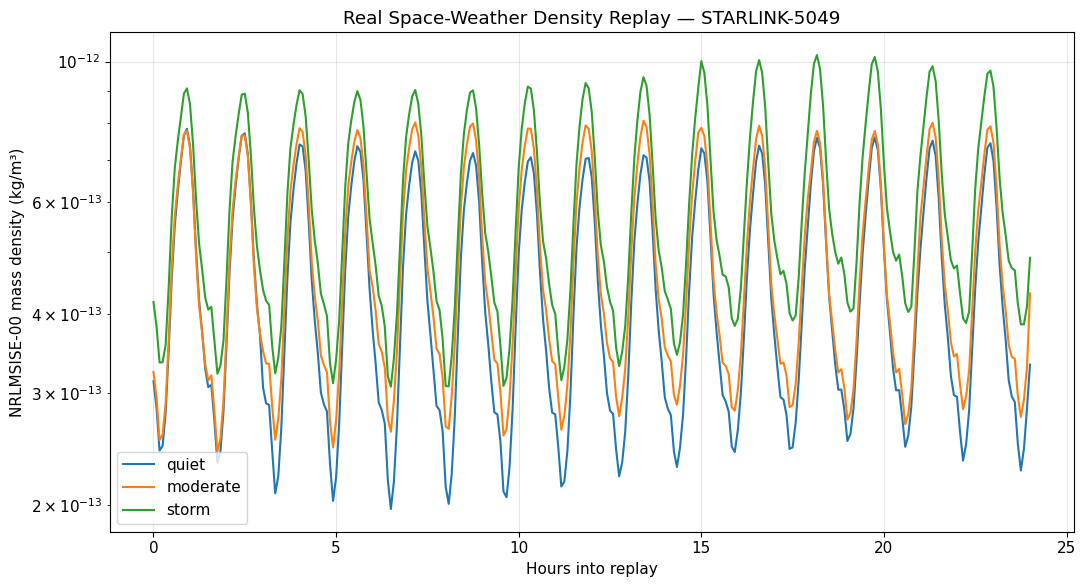

✅ Saved density diagnostics


In [ ]:
# C5 — Density summary and representative plot

density_rows = []

for (
    norad,
    weather_label,
), prof in (
    density_profiles.items()
):

    density_rows.append({
        "norad": norad,
        "name": prof["name"],
        "shell": prof["shell"],
        "weather": weather_label,
        "median_density_kg_m3": float(
            np.median(
                prof[
                    "rho_kg_m3"
                ]
            )
        ),
        "p95_density_kg_m3": float(
            np.percentile(
                prof[
                    "rho_kg_m3"
                ],
                95,
            )
        ),
        "max_density_kg_m3": float(
            np.max(
                prof[
                    "rho_kg_m3"
                ]
            )
        ),
        "min_alt_km": float(
            np.min(
                prof[
                    "alt_km"
                ]
            )
        ),
        "max_alt_km": float(
            np.max(
                prof[
                    "alt_km"
                ]
            )
        ),
    })


density_summary = pd.DataFrame(
    density_rows
)

DENSITY_SUMMARY_PATH = (
    OUTPUT_DIR
    / "real_MSIS_density_summary.csv"
)

density_summary.to_csv(
    DENSITY_SUMMARY_PATH,
    index=False,
)

display(
    density_summary
)


demo_row = (
    train_rep_df
    .sort_values(
        "APPROX_ALT_KM"
    )
    .iloc[
        len(train_rep_df)//2
    ]
)

DEMO_NORAD = int(
    demo_row[
        "NORAD_CAT_ID"
    ]
)


plt.figure(
    figsize=(11, 6)
)

for weather_label in [
    "quiet",
    "moderate",
    "storm",
]:

    prof = density_profiles[
        (
            DEMO_NORAD,
            weather_label,
        )
    ]

    plt.semilogy(
        prof["time_hr"],
        prof["rho_kg_m3"],
        label=weather_label,
    )


plt.xlabel(
    "Hours into replay"
)

plt.ylabel(
    "NRLMSISE-00 mass density (kg/m³)"
)

plt.title(
    f"Real Space-Weather Density Replay — "
    f"{demo_row['OBJECT_NAME']}"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

DENSITY_PLOT = (
    OUTPUT_DIR
    / "real_MSIS_density_demo.png"
)

plt.savefig(
    DENSITY_PLOT,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "✅ Saved density diagnostics"
)

# 5 — Physical drag truth model

Atmospheric drag acceleration is now computed from:

\[
\mathbf a_D =
-\frac{1}{2}
C_D \frac{A}{m}
\rho
\left\lVert \mathbf v_\mathrm{rel}\right\rVert^2
\hat{\mathbf v}_\mathrm{rel}
\]

where atmospheric co-rotation is included through:

\[
\mathbf v_\mathrm{rel}
=
\mathbf v
-
\boldsymbol{\omega}_E
\times
\mathbf r.
\]

For Week-1b calibration:

- \(C_D = 2.2\)
- \(A/m = 0.02~\mathrm{m^2/kg}\)

No arbitrary storm multiplier is used. The time variation comes from NRLMSISE-00 density driven by the historical F10.7/Ap record.

In [ ]:
# D0 — Nominal two-body + J2 dynamics

def accel_two_body_j2(
    r,
):

    r = np.asarray(
        r,
        dtype=float,
    )

    x, y, z = r

    r2 = np.dot(
        r,
        r,
    )

    rn = np.sqrt(
        r2
    )

    a_two_body = (
        -MU_EARTH
        * r
        / rn**3
    )

    z2 = z*z

    common = (
        5.0*z2/r2
    )

    factor = (
        1.5
        * J2
        * MU_EARTH
        * R_EARTH**2
        / rn**5
    )

    a_j2 = factor * np.array([
        x*(common-1.0),
        y*(common-1.0),
        z*(common-3.0),
    ])

    return (
        a_two_body
        + a_j2
    )


def nominal_derivative(
    x,
):

    return np.concatenate([
        x[3:],
        accel_two_body_j2(
            x[:3]
        ),
    ])


def rk4_nominal_step(
    x,
    dt,
):

    k1 = nominal_derivative(
        x
    )

    k2 = nominal_derivative(
        x
        + 0.5*dt*k1
    )

    k3 = nominal_derivative(
        x
        + 0.5*dt*k2
    )

    k4 = nominal_derivative(
        x
        + dt*k3
    )

    return (
        x
        + dt/6.0
        * (
            k1
            + 2*k2
            + 2*k3
            + k4
        )
    )


def propagate_nominal(
    x0,
    n_steps,
    dt,
):

    states = np.zeros(
        (n_steps, 6)
    )

    states[0] = x0

    for k in range(
        1,
        n_steps,
    ):

        states[k] = (
            rk4_nominal_step(
                states[k-1],
                dt,
            )
        )

    return states


print(
    "✅ Nominal dynamics defined"
)

✅ Nominal dynamics defined


In [ ]:
# D1 — Physical atmospheric-drag truth dynamics

DRAG_COEFFICIENT = 2.2

AREA_TO_MASS_M2_KG = (
    0.02
)


def physical_drag_acceleration(
    r_km,
    v_km_s,
    rho_kg_m3,
    cd=DRAG_COEFFICIENT,
    area_to_mass=AREA_TO_MASS_M2_KG,
):

    atmosphere_velocity = (
        np.cross(
            OMEGA_EARTH,
            r_km,
        )
    )

    v_rel_km_s = (
        v_km_s
        - atmosphere_velocity
    )

    speed_rel_m_s = (
        np.linalg.norm(
            v_rel_km_s
        )
        * 1000.0
    )

    v_hat = (
        v_rel_km_s
        / (
            np.linalg.norm(
                v_rel_km_s
            )
            + 1e-15
        )
    )

    accel_m_s2 = (
        0.5
        * cd
        * area_to_mass
        * rho_kg_m3
        * speed_rel_m_s**2
    )

    return (
        -accel_m_s2
        / 1000.0
        * v_hat
    )


def truth_derivative_real_drag(
    x,
    t_seconds,
    density_profile,
):

    rho = float(
        np.interp(
            t_seconds,
            density_profile[
                "time_s"
            ],
            density_profile[
                "rho_kg_m3"
            ],
        )
    )

    r = x[:3]
    v = x[3:]

    a = (
        accel_two_body_j2(
            r
        )
        +
        physical_drag_acceleration(
            r,
            v,
            rho,
        )
    )

    return np.concatenate([
        v,
        a,
    ])


def rk4_truth_real_drag_step(
    x,
    t_seconds,
    dt,
    density_profile,
):

    k1 = (
        truth_derivative_real_drag(
            x,
            t_seconds,
            density_profile,
        )
    )

    k2 = (
        truth_derivative_real_drag(
            x
            + 0.5*dt*k1,
            t_seconds
            + 0.5*dt,
            density_profile,
        )
    )

    k3 = (
        truth_derivative_real_drag(
            x
            + 0.5*dt*k2,
            t_seconds
            + 0.5*dt,
            density_profile,
        )
    )

    k4 = (
        truth_derivative_real_drag(
            x
            + dt*k3,
            t_seconds
            + dt,
            density_profile,
        )
    )

    return (
        x
        + dt/6.0
        * (
            k1
            + 2*k2
            + 2*k3
            + k4
        )
    )


def propagate_truth_real_drag(
    x0,
    n_steps,
    dt,
    density_profile,
):

    states = np.zeros(
        (n_steps, 6)
    )

    states[0] = x0

    for k in range(
        1,
        n_steps,
    ):

        states[k] = (
            rk4_truth_real_drag_step(
                states[k-1],
                (k-1)*dt,
                dt,
                density_profile,
            )
        )

        altitude = (
            np.linalg.norm(
                states[k, :3]
            )
            - R_EARTH
        )

        if altitude < 120:

            states[
                k+1:
            ] = np.nan

            print(
                "⚠️ Trajectory crossed "
                "120 km; propagation stopped"
            )

            break

    return states


print(
    "✅ Physical-drag truth model defined"
)

✅ Physical-drag truth model defined


In [ ]:
# D2 — Generate multi-object real-weather truth trajectories

real_truth_cases = {}

divergence_rows = []

for _, row in (
    train_rep_df.iterrows()
):

    norad = int(
        row[
            "NORAD_CAT_ID"
        ]
    )

    sat = satrec_by_norad[
        norad
    ]

    r0, v0 = (
        sgp4_state_at_offset(
            sat,
            0.0,
        )
    )

    x0 = np.concatenate([
        r0,
        v0,
    ])

    nominal = (
        propagate_nominal(
            x0,
            DYN_N_STEPS,
            DYN_DT,
        )
    )

    sgp4_24h = (
        sgp4_series(
            sat,
            DYN_DT,
            hours=DYN_HOURS,
        )
    )

    for weather_label in [
        "quiet",
        "moderate",
        "storm",
    ]:

        density_profile = (
            density_profiles[
                (
                    norad,
                    weather_label,
                )
            ]
        )

        print(
            f"Physical truth: "
            f"{row['OBJECT_NAME']} | "
            f"{weather_label}"
        )

        truth = (
            propagate_truth_real_drag(
                x0,
                DYN_N_STEPS,
                DYN_DT,
                density_profile,
            )
        )

        valid = np.all(
            np.isfinite(
                truth
            ),
            axis=1,
        )

        if valid.sum() < 2:

            raise RuntimeError(
                "Truth propagation failed."
            )

        nominal_error = (
            np.linalg.norm(
                truth[
                    valid,
                    :3,
                ]
                -
                nominal[
                    valid,
                    :3,
                ],
                axis=1,
            )
        )

        sgp4_error = (
            np.linalg.norm(
                truth[
                    valid,
                    :3,
                ]
                -
                sgp4_24h[
                    valid,
                    :3,
                ],
                axis=1,
            )
        )

        real_truth_cases[
            (
                norad,
                weather_label,
            )
        ] = {
            "row": row.to_dict(),
            "x0": x0,
            "truth": truth,
            "nominal": nominal,
            "sgp4": sgp4_24h,
            "density_profile": (
                density_profile
            ),
        }

        divergence_rows.append({
            "name": row[
                "OBJECT_NAME"
            ],
            "norad": norad,
            "shell": row[
                "SHELL"
            ],
            "weather": weather_label,
            "start_alt_km": (
                np.linalg.norm(r0)
                - R_EARTH
            ),
            "final_truth_vs_nominal_km": float(
                nominal_error[-1]
            ),
            "max_truth_vs_nominal_km": float(
                nominal_error.max()
            ),
            "final_truth_vs_sgp4_km": float(
                sgp4_error[-1]
            ),
            "max_truth_vs_sgp4_km": float(
                sgp4_error.max()
            ),
            "completed_hours": float(
                (
                    valid.sum()-1
                )
                * DYN_DT
                / 3600.0
            ),
        })


real_divergence_df = pd.DataFrame(
    divergence_rows
)

REAL_DIVERGENCE_PATH = (
    OUTPUT_DIR
    / "real_weather_multiobject_divergence.csv"
)

real_divergence_df.to_csv(
    REAL_DIVERGENCE_PATH,
    index=False,
)

display(
    real_divergence_df.round(3)
)

print(
    "✅ Real-weather physical-drag trajectories complete"
)

Physical truth: STARLINK-5049 | quiet
Physical truth: STARLINK-5049 | moderate
Physical truth: STARLINK-5049 | storm
Physical truth: STARLINK-1193 | quiet
Physical truth: STARLINK-1193 | moderate
Physical truth: STARLINK-1193 | storm
Physical truth: STARLINK-34312 | quiet
Physical truth: STARLINK-34312 | moderate
Physical truth: STARLINK-34312 | storm
Physical truth: STARLINK-36698 | quiet
Physical truth: STARLINK-36698 | moderate
Physical truth: STARLINK-36698 | storm


,name,norad,shell,weather,start_alt_km,final_truth_vs_nominal_km,max_truth_vs_nominal_km,final_truth_vs_sgp4_km,max_truth_vs_sgp4_km,completed_hours
0,STARLINK-5049,57246,43deg,quiet,483.630,5.760,5.760,18.769,18.777,24.0
1,STARLINK-5049,57246,43deg,moderate,483.630,6.350,6.350,19.359,19.365,24.0
2,STARLINK-5049,57246,43deg,storm,483.630,7.615,7.615,20.624,20.627,24.0
3,STARLINK-1193,45100,53deg,quiet,332.639,78.394,78.394,48.870,48.870,24.0
4,STARLINK-1193,45100,53deg,moderate,332.639,84.136,84.136,54.611,54.611,24.0
5,STARLINK-1193,45100,53deg,storm,332.639,96.242,96.242,66.717,66.717,24.0
6,STARLINK-34312,64711,70deg,quiet,575.946,1.384,1.384,3.329,3.844,24.0
7,STARLINK-34312,64711,70deg,moderate,575.946,1.591,1.591,3.536,4.038,24.0
8,STARLINK-34312,64711,70deg,storm,575.946,1.969,1.969,3.914,4.387,24.0
9,STARLINK-36698,67709,97deg,quiet,470.419,7.190,7.190,5.359,6.378,24.0


✅ Real-weather physical-drag trajectories complete


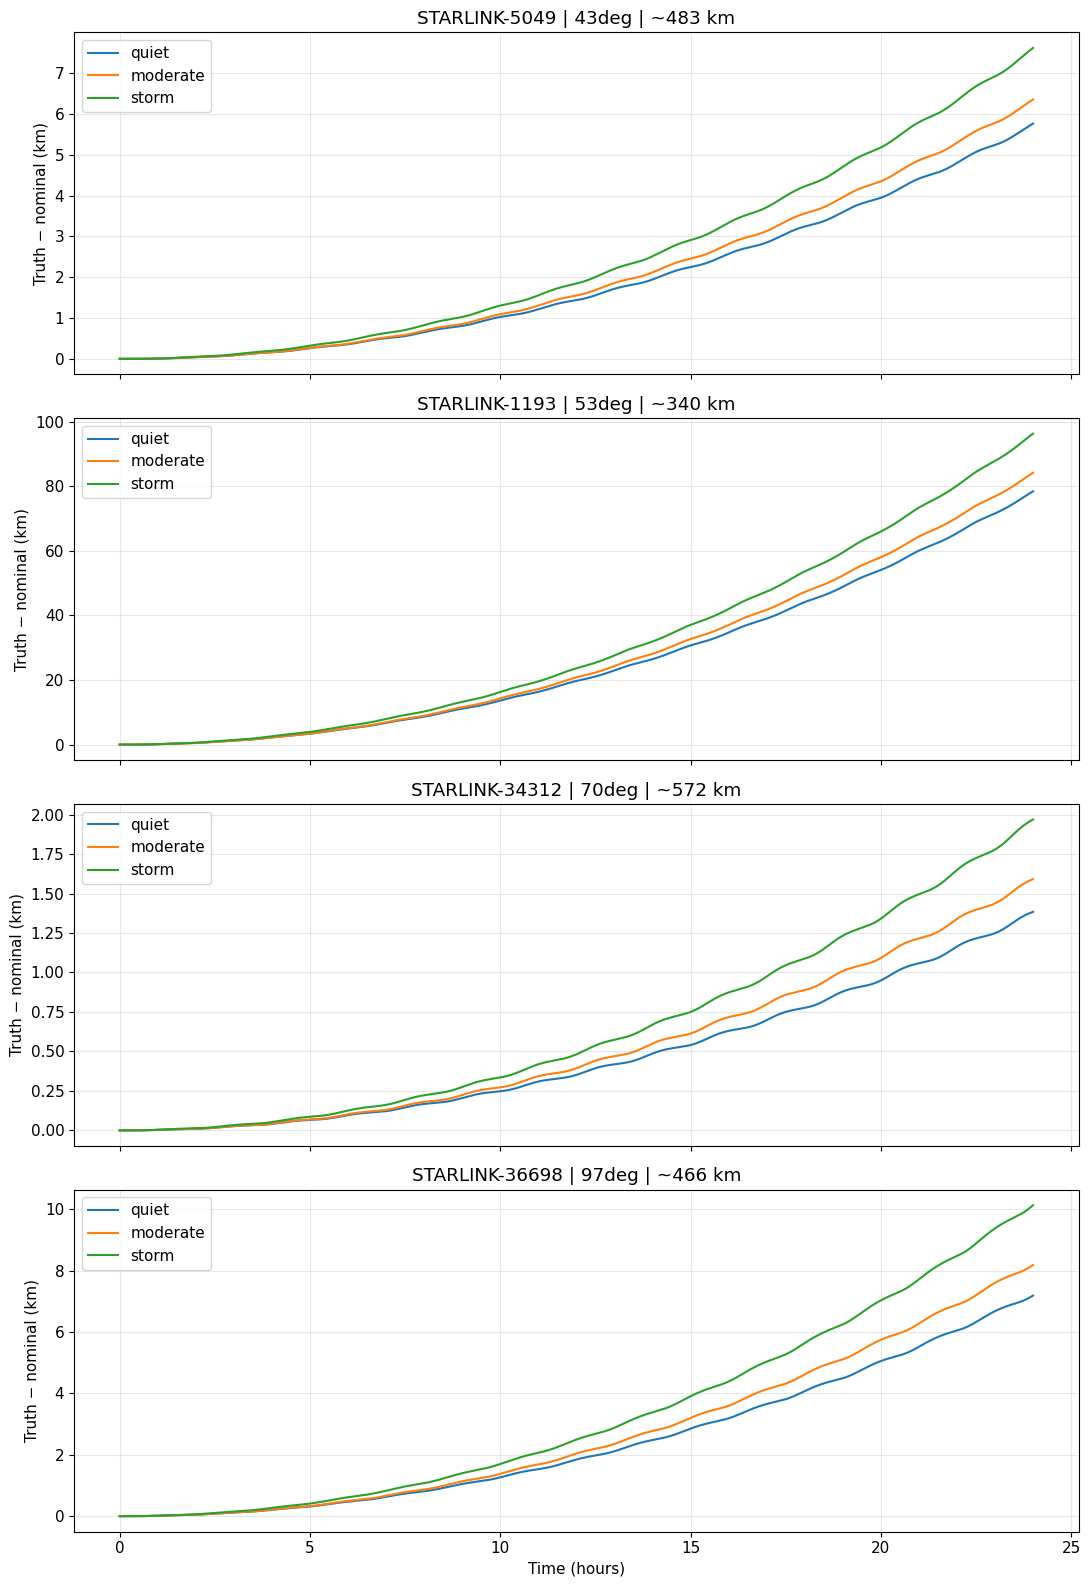

✅ Saved: /content/IAC2026_FINAL_WEEK1B/outputs/real_weather_multiobject_divergence.png


In [ ]:
# D3 — Plot truth-vs-nominal divergence for each TRAIN representative

fig, axes = plt.subplots(
    len(train_rep_df),
    1,
    figsize=(
        11,
        4*len(train_rep_df),
    ),
    sharex=True,
)

if len(train_rep_df) == 1:
    axes = [axes]

for ax, (_, row) in zip(
    axes,
    train_rep_df.iterrows(),
):

    norad = int(
        row["NORAD_CAT_ID"]
    )

    for weather_label in [
        "quiet",
        "moderate",
        "storm",
    ]:

        case = real_truth_cases[
            (
                norad,
                weather_label,
            )
        ]

        truth = case["truth"]
        nominal = case["nominal"]

        valid = np.all(
            np.isfinite(
                truth
            ),
            axis=1,
        )

        error = np.linalg.norm(
            truth[
                valid,
                :3,
            ]
            -
            nominal[
                valid,
                :3,
            ],
            axis=1,
        )

        time_hr = (
            np.arange(
                len(error)
            )
            * DYN_DT
            / 3600.0
        )

        ax.plot(
            time_hr,
            error,
            label=weather_label,
        )

    ax.set_ylabel(
        "Truth − nominal (km)"
    )

    ax.set_title(
        f"{row['OBJECT_NAME']} | "
        f"{row['SHELL']} | "
        f"~{row['APPROX_ALT_KM']:.0f} km"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend()


axes[-1].set_xlabel(
    "Time (hours)"
)

plt.tight_layout()

REAL_DIVERGENCE_PLOT = (
    OUTPUT_DIR
    / "real_weather_multiobject_divergence.png"
)

plt.savefig(
    REAL_DIVERGENCE_PLOT,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "✅ Saved:",
    REAL_DIVERGENCE_PLOT,
)

# ✅ CHECKPOINT — Inspect before caring about the ML

At this point we can answer a major scientific question:

> What trajectory mismatch arises from a physical drag model driven by real historical F10.7/Ap and NRLMSISE-00 density?

We have not tuned the disturbance magnitude to make any AI method win.

If these trajectories look sensible, continue to the EKF calibration below.

# 6 — Observations and corrected Cartesian EKF

The measurement model remains the same simplified noisy Cartesian-position abstraction used in the earlier benchmark.

Week-1b re-tunes process noise because the truth model has changed from synthetic drag-like forcing to physical NRLMSISE-00-driven drag.

**No TEST satellite is used.**

In [ ]:
# E0 — Observation helpers

R_STD = 0.5  # km/component


def build_observation_indices(
    n_steps,
    dt_seconds,
    cadence_min,
    outages_hr=None,
):

    if outages_hr is None:
        outages_hr = []

    cadence_steps = int(
        round(
            cadence_min
            * 60.0
            / dt_seconds
        )
    )

    indices = np.arange(
        0,
        n_steps,
        cadence_steps,
        dtype=int,
    )

    times_hr = (
        indices
        * dt_seconds
        / 3600.0
    )

    keep = np.ones(
        len(indices),
        dtype=bool,
    )

    for start_hr, end_hr in (
        outages_hr
    ):

        keep &= ~(
            (
                times_hr
                >= start_hr
            )
            &
            (
                times_hr
                < end_hr
            )
        )

    return indices[
        keep
    ]


def make_observations(
    truth,
    obs_indices,
    seed,
):

    rng = np.random.default_rng(
        int(seed)
    )

    noise = rng.normal(
        0.0,
        R_STD,
        size=(
            len(truth),
            3,
        ),
    )

    return (
        truth[
            obs_indices,
            :3,
        ]
        +
        noise[
            obs_indices
        ]
    )


print(
    "✅ Observation helpers defined"
)

✅ Observation helpers defined


In [ ]:
# E1 — Correct state-dependent Cartesian EKF

def constant_acceleration_Q(
    dt_seconds,
    sigma_a,
):

    I3 = np.eye(3)

    return (
        sigma_a**2
        * np.block([
            [
                0.25
                * dt_seconds**4
                * I3,
                0.5
                * dt_seconds**3
                * I3,
            ],
            [
                0.5
                * dt_seconds**3
                * I3,
                dt_seconds**2
                * I3,
            ],
        ])
    )


def numerical_transition_jacobian(
    x,
    dt_seconds,
    eps_pos_km=1e-3,
    eps_vel_km_s=1e-6,
):

    f0 = rk4_nominal_step(
        x,
        dt_seconds,
    )

    eps = np.array(
        [eps_pos_km]*3
        + [eps_vel_km_s]*3
    )

    F = np.zeros(
        (6, 6)
    )

    for i in range(6):

        xp = x.copy()

        xp[i] += eps[i]

        fp = rk4_nominal_step(
            xp,
            dt_seconds,
        )

        F[:, i] = (
            fp - f0
        ) / eps[i]

    return F


class CartesianOrbitEKF:

    def __init__(
        self,
        dt_seconds,
        r_std_km,
        sigma_a_km_s2,
    ):

        self.dt = float(
            dt_seconds
        )

        self.R = (
            np.eye(3)
            * r_std_km**2
        )

        self.H = np.eye(
            3,
            6,
        )

        self.Q = (
            constant_acceleration_Q(
                self.dt,
                sigma_a_km_s2,
            )
        )

        self.sigma_a = (
            sigma_a_km_s2
        )


    def _predict(
        self,
        x,
        P,
    ):

        F = (
            numerical_transition_jacobian(
                x,
                self.dt,
            )
        )

        x_pred = (
            rk4_nominal_step(
                x,
                self.dt,
            )
        )

        P_pred = (
            F
            @ P
            @ F.T
            + self.Q
        )

        return (
            x_pred,
            0.5
            * (
                P_pred
                + P_pred.T
            ),
        )


    def _update(
        self,
        x,
        P,
        z,
    ):

        innovation = (
            z
            - self.H
            @ x
        )

        S = (
            self.H
            @ P
            @ self.H.T
            + self.R
        )

        K = np.linalg.solve(
            S,
            (
                P
                @ self.H.T
            ).T,
        ).T

        x_new = (
            x
            + K
            @ innovation
        )

        I = np.eye(6)

        KH = (
            K
            @ self.H
        )

        P_new = (
            (I-KH)
            @ P
            @ (I-KH).T
            +
            K
            @ self.R
            @ K.T
        )

        P_new = (
            0.5
            * (
                P_new
                + P_new.T
            )
        )

        nis = float(
            innovation.T
            @ np.linalg.solve(
                S,
                innovation,
            )
        )

        return (
            x_new,
            P_new,
            innovation,
            nis,
        )


    def run(
        self,
        x0,
        P0,
        n_steps,
        observation_times,
        observations,
    ):

        obs_dict = {
            int(k): np.asarray(
                z,
                dtype=float,
            )
            for k, z in zip(
                observation_times,
                observations,
            )
        }

        x = np.asarray(
            x0,
            dtype=float,
        ).copy()

        P = np.asarray(
            P0,
            dtype=float,
        ).copy()

        estimates = np.zeros(
            (n_steps, 6)
        )

        covariances = np.zeros(
            (n_steps, 6, 6)
        )

        innovations = np.full(
            (n_steps, 3),
            np.nan,
        )

        nis = np.full(
            n_steps,
            np.nan,
        )

        if 0 in obs_dict:

            (
                x,
                P,
                inn,
                nis0,
            ) = self._update(
                x,
                P,
                obs_dict[0],
            )

            innovations[0] = inn
            nis[0] = nis0

        estimates[0] = x
        covariances[0] = P

        for k in range(
            1,
            n_steps,
        ):

            x, P = (
                self._predict(
                    x,
                    P,
                )
            )

            if k in obs_dict:

                (
                    x,
                    P,
                    inn,
                    nisk,
                ) = self._update(
                    x,
                    P,
                    obs_dict[k],
                )

                innovations[k] = inn
                nis[k] = nisk

            estimates[k] = x
            covariances[k] = P

        return {
            "estimates": estimates,
            "covariances": covariances,
            "innovations": innovations,
            "nis": nis,
        }


print(
    "✅ Correct EKF defined"
)

✅ Correct EKF defined


In [ ]:
# E2 — Metric helpers

P0 = np.diag(
    [2.0**2]*3
    + [0.002**2]*3
)


def position_rmse(
    estimate,
    truth,
):

    valid = (
        np.all(
            np.isfinite(
                truth
            ),
            axis=1,
        )
        &
        np.all(
            np.isfinite(
                estimate
            ),
            axis=1,
        )
    )

    error = np.linalg.norm(
        estimate[
            valid,
            :3,
        ]
        -
        truth[
            valid,
            :3,
        ],
        axis=1,
    )

    return float(
        np.sqrt(
            np.mean(
                error**2
            )
        )
    )


def run_ekf_case(
    truth,
    x0_nominal,
    sigma_a,
    obs_seed,
    init_seed,
    cadence_min=10,
    outages_hr=None,
):

    if outages_hr is None:
        outages_hr = []

    obs_indices = (
        build_observation_indices(
            len(truth),
            DYN_DT,
            cadence_min,
            outages_hr,
        )
    )

    observations = (
        make_observations(
            truth,
            obs_indices,
            obs_seed,
        )
    )

    rng = np.random.default_rng(
        int(init_seed)
    )

    x0_est = (
        x0_nominal.copy()
    )

    x0_est[:3] += rng.normal(
        0.0,
        2.0,
        3,
    )

    x0_est[3:] += rng.normal(
        0.0,
        0.002,
        3,
    )

    filt = (
        CartesianOrbitEKF(
            DYN_DT,
            R_STD,
            sigma_a,
        )
        .run(
            x0_est,
            P0.copy(),
            len(truth),
            obs_indices,
            observations,
        )
    )

    rmse = position_rmse(
        filt[
            "estimates"
        ],
        truth,
    )

    valid_nis = (
        filt["nis"][
            np.isfinite(
                filt["nis"]
            )
        ]
    )

    return {
        "rmse_km": rmse,
        "mean_nis": float(
            np.mean(
                valid_nis
            )
        ),
        "median_nis": float(
            np.median(
                valid_nis
            )
        ),
        "n_observations": int(
            len(
                obs_indices
            )
        ),
        "filter": filt,
        "obs_indices": (
            obs_indices
        ),
    }


print(
    "✅ EKF experiment helper defined"
)

✅ EKF experiment helper defined


# 7 — Re-tune EKF process noise on the NEW physical truth model

The old \(3	imes10^{-7}\) value came from the earlier synthetic 3-hour experiment and is **not assumed optimal here**.

### Development protocol

**Training calibration**
- representative TRAIN object from each inclination shell;
- quiet + moderate + storm real-weather replay;
- 10-minute observations;
- five candidate process-noise values.

**Validation selection**
- take the two strongest candidates from TRAIN RMSE;
- evaluate them on representative VALIDATION objects;
- select the lower validation mean RMSE;
- report NIS rather than hiding it.

**TEST objects are untouched.**

In [ ]:
# F0 — Training Q sweep

Q_CANDIDATES = np.array([
    3e-8,
    1e-7,
    3e-7,
    1e-6,
    3e-6,
])

q_train_rows = []


for _, row in (
    train_rep_df.iterrows()
):

    norad = int(
        row[
            "NORAD_CAT_ID"
        ]
    )

    for weather_label in [
        "quiet",
        "moderate",
        "storm",
    ]:

        case = (
            real_truth_cases[
                (
                    norad,
                    weather_label,
                )
            ]
        )

        truth = case[
            "truth"
        ]

        if not np.all(
            np.isfinite(
                truth
            )
        ):

            print(
                "Skipping incomplete trajectory:",
                row[
                    "OBJECT_NAME"
                ],
                weather_label,
            )

            continue

        x0 = case[
            "x0"
        ]

        scenario_code = (
            int(norad)
            + {
                "quiet": 1000,
                "moderate": 2000,
                "storm": 3000,
            }[
                weather_label
            ]
        )

        for sigma_a in (
            Q_CANDIDATES
        ):

            print(
                f"TRAIN Q: "
                f"{row['OBJECT_NAME']} | "
                f"{weather_label} | "
                f"{sigma_a:.1e}"
            )

            result = (
                run_ekf_case(
                    truth,
                    x0,
                    sigma_a,
                    obs_seed=(
                        500000
                        + scenario_code
                    ),
                    init_seed=(
                        600000
                        + scenario_code
                    ),
                    cadence_min=10,
                )
            )

            q_train_rows.append({
                "name": row[
                    "OBJECT_NAME"
                ],
                "norad": norad,
                "shell": row[
                    "SHELL"
                ],
                "weather": weather_label,
                "sigma_a": sigma_a,
                "rmse_km": result[
                    "rmse_km"
                ],
                "mean_nis": result[
                    "mean_nis"
                ],
            })


q_train_df = pd.DataFrame(
    q_train_rows
)

Q_TRAIN_PATH = (
    OUTPUT_DIR
    / "real_weather_Q_sweep_TRAIN.csv"
)

q_train_df.to_csv(
    Q_TRAIN_PATH,
    index=False,
)


q_train_summary = (
    q_train_df
    .groupby("sigma_a")
    .agg(
        mean_rmse_km=(
            "rmse_km",
            "mean",
        ),
        median_rmse_km=(
            "rmse_km",
            "median",
        ),
        mean_nis=(
            "mean_nis",
            "mean",
        ),
        n_cases=(
            "rmse_km",
            "size",
        ),
    )
    .reset_index()
    .sort_values(
        "mean_rmse_km"
    )
)


display(
    q_train_summary
)


TOP2_Q = (
    q_train_summary[
        "sigma_a"
    ]
    .iloc[:2]
    .to_numpy()
)


print(
    "✅ Top two TRAIN candidates:",
    [
        f"{x:.1e}"
        for x in TOP2_Q
    ]
)

TRAIN Q: STARLINK-5049 | quiet | 3.0e-08
TRAIN Q: STARLINK-5049 | quiet | 1.0e-07
TRAIN Q: STARLINK-5049 | quiet | 3.0e-07
TRAIN Q: STARLINK-5049 | quiet | 1.0e-06
TRAIN Q: STARLINK-5049 | quiet | 3.0e-06
TRAIN Q: STARLINK-5049 | moderate | 3.0e-08
TRAIN Q: STARLINK-5049 | moderate | 1.0e-07
TRAIN Q: STARLINK-5049 | moderate | 3.0e-07
TRAIN Q: STARLINK-5049 | moderate | 1.0e-06
TRAIN Q: STARLINK-5049 | moderate | 3.0e-06
TRAIN Q: STARLINK-5049 | storm | 3.0e-08
TRAIN Q: STARLINK-5049 | storm | 1.0e-07
TRAIN Q: STARLINK-5049 | storm | 3.0e-07
TRAIN Q: STARLINK-5049 | storm | 1.0e-06
TRAIN Q: STARLINK-5049 | storm | 3.0e-06
TRAIN Q: STARLINK-1193 | quiet | 3.0e-08
TRAIN Q: STARLINK-1193 | quiet | 1.0e-07
TRAIN Q: STARLINK-1193 | quiet | 3.0e-07
TRAIN Q: STARLINK-1193 | quiet | 1.0e-06
TRAIN Q: STARLINK-1193 | quiet | 3.0e-06
TRAIN Q: STARLINK-1193 | moderate | 3.0e-08
TRAIN Q: STARLINK-1193 | moderate | 1.0e-07
TRAIN Q: STARLINK-1193 | moderate | 3.0e-07
TRAIN Q: STARLINK-1193 | moderate

,sigma_a,mean_rmse_km,median_rmse_km,mean_nis,n_cases
0,3.000000e-08,0.388202,0.371431,3.101967,12
1,1.000000e-07,0.406350,0.408068,2.852738,12
2,3.000000e-07,0.510673,0.519189,2.706493,12
3,1.000000e-06,0.670012,0.681570,2.499383,12
4,3.000000e-06,0.861751,0.865646,2.151428,12


✅ Top two TRAIN candidates: ['3.0e-08', '1.0e-07']


In [ ]:
# F1 — Build real-density + physical truth cases for VALIDATION representatives

validation_truth_cases = {}

for _, row in (
    val_rep_df.iterrows()
):

    norad = int(
        row[
            "NORAD_CAT_ID"
        ]
    )

    sat = satrec_by_norad[
        norad
    ]

    r0, v0 = (
        sgp4_state_at_offset(
            sat,
            0.0,
        )
    )

    x0 = np.concatenate([
        r0,
        v0,
    ])

    for weather_label in [
        "quiet",
        "moderate",
        "storm",
    ]:

        print(
            f"VALIDATION density/truth: "
            f"{row['OBJECT_NAME']} | "
            f"{weather_label}"
        )

        density_prof = (
            real_density_profile_for_object(
                row,
                weather_label,
            )
        )

        truth = (
            propagate_truth_real_drag(
                x0,
                DYN_N_STEPS,
                DYN_DT,
                density_prof,
            )
        )

        validation_truth_cases[
            (
                norad,
                weather_label,
            )
        ] = {
            "row": row.to_dict(),
            "x0": x0,
            "truth": truth,
            "density_profile": (
                density_prof
            ),
        }


print(
    "✅ VALIDATION physical truth cases generated"
)

VALIDATION density/truth: STARLINK-30327 | quiet
VALIDATION density/truth: STARLINK-30327 | moderate
VALIDATION density/truth: STARLINK-30327 | storm
VALIDATION density/truth: STARLINK-2446 | quiet
VALIDATION density/truth: STARLINK-2446 | moderate
VALIDATION density/truth: STARLINK-2446 | storm
VALIDATION density/truth: STARLINK-38033 | quiet
VALIDATION density/truth: STARLINK-38033 | moderate
VALIDATION density/truth: STARLINK-38033 | storm
✅ VALIDATION physical truth cases generated


In [ ]:
# F2 — Evaluate top two Q candidates on VALIDATION only

q_val_rows = []

for _, row in (
    val_rep_df.iterrows()
):

    norad = int(
        row[
            "NORAD_CAT_ID"
        ]
    )

    for weather_label in [
        "quiet",
        "moderate",
        "storm",
    ]:

        case = (
            validation_truth_cases[
                (
                    norad,
                    weather_label,
                )
            ]
        )

        truth = case[
            "truth"
        ]

        if not np.all(
            np.isfinite(
                truth
            )
        ):

            print(
                "Skipping incomplete validation trajectory:",
                row[
                    "OBJECT_NAME"
                ],
                weather_label,
            )

            continue

        x0 = case[
            "x0"
        ]

        scenario_code = (
            int(norad)
            + {
                "quiet": 1000,
                "moderate": 2000,
                "storm": 3000,
            }[
                weather_label
            ]
        )

        for sigma_a in (
            TOP2_Q
        ):

            print(
                f"VAL Q: "
                f"{row['OBJECT_NAME']} | "
                f"{weather_label} | "
                f"{sigma_a:.1e}"
            )

            result = (
                run_ekf_case(
                    truth,
                    x0,
                    sigma_a,
                    obs_seed=(
                        700000
                        + scenario_code
                    ),
                    init_seed=(
                        800000
                        + scenario_code
                    ),
                    cadence_min=10,
                )
            )

            q_val_rows.append({
                "name": row[
                    "OBJECT_NAME"
                ],
                "norad": norad,
                "shell": row[
                    "SHELL"
                ],
                "weather": weather_label,
                "sigma_a": sigma_a,
                "rmse_km": result[
                    "rmse_km"
                ],
                "mean_nis": result[
                    "mean_nis"
                ],
            })


q_val_df = pd.DataFrame(
    q_val_rows
)

Q_VAL_PATH = (
    OUTPUT_DIR
    / "real_weather_Q_sweep_VALIDATION.csv"
)

q_val_df.to_csv(
    Q_VAL_PATH,
    index=False,
)


q_val_summary = (
    q_val_df
    .groupby(
        "sigma_a"
    )
    .agg(
        mean_rmse_km=(
            "rmse_km",
            "mean",
        ),
        median_rmse_km=(
            "rmse_km",
            "median",
        ),
        mean_nis=(
            "mean_nis",
            "mean",
        ),
        n_cases=(
            "rmse_km",
            "size",
        ),
    )
    .reset_index()
    .sort_values(
        "mean_rmse_km"
    )
)


display(
    q_val_summary
)


SIGMA_A_WEEK1B = float(
    q_val_summary[
        "sigma_a"
    ]
    .iloc[0]
)


print()
print(
    "✅ Week-1b selected process noise:"
)

print(
    f"   sigma_a = "
    f"{SIGMA_A_WEEK1B:.1e} km/s²"
)

print(
    "   Selection used TRAIN + VALIDATION only."
)

print(
    "   TEST satellites remain untouched."
)

VAL Q: STARLINK-30327 | quiet | 3.0e-08
VAL Q: STARLINK-30327 | quiet | 1.0e-07
VAL Q: STARLINK-30327 | moderate | 3.0e-08
VAL Q: STARLINK-30327 | moderate | 1.0e-07
VAL Q: STARLINK-30327 | storm | 3.0e-08
VAL Q: STARLINK-30327 | storm | 1.0e-07
VAL Q: STARLINK-2446 | quiet | 3.0e-08
VAL Q: STARLINK-2446 | quiet | 1.0e-07
VAL Q: STARLINK-2446 | moderate | 3.0e-08
VAL Q: STARLINK-2446 | moderate | 1.0e-07
VAL Q: STARLINK-2446 | storm | 3.0e-08
VAL Q: STARLINK-2446 | storm | 1.0e-07
VAL Q: STARLINK-38033 | quiet | 3.0e-08
VAL Q: STARLINK-38033 | quiet | 1.0e-07
VAL Q: STARLINK-38033 | moderate | 3.0e-08
VAL Q: STARLINK-38033 | moderate | 1.0e-07
VAL Q: STARLINK-38033 | storm | 3.0e-08
VAL Q: STARLINK-38033 | storm | 1.0e-07


,sigma_a,mean_rmse_km,median_rmse_km,mean_nis,n_cases
0,3.000000e-08,0.339172,0.337995,2.945169,9
1,1.000000e-07,0.390399,0.397594,2.827111,9



✅ Week-1b selected process noise:
   sigma_a = 3.0e-08 km/s²
   Selection used TRAIN + VALIDATION only.
   TEST satellites remain untouched.


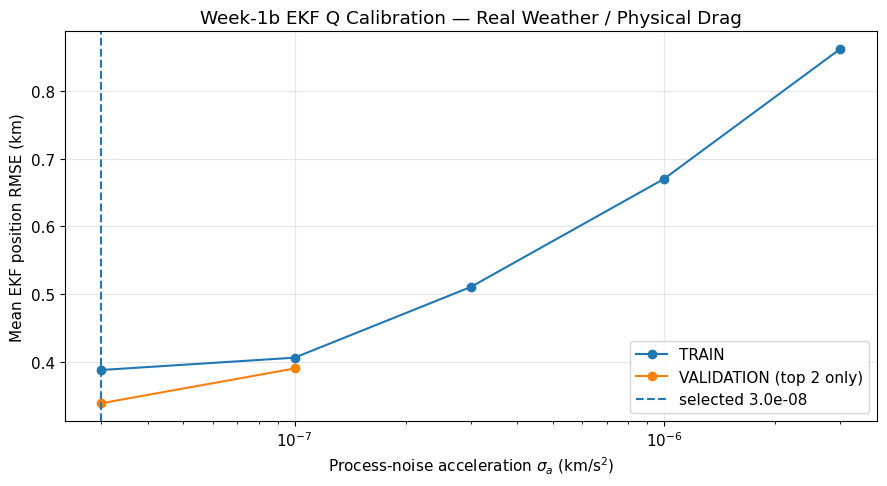

✅ Saved: /content/IAC2026_FINAL_WEEK1B/outputs/real_weather_Q_calibration.png


In [ ]:
# F3 — Plot Q calibration results

plt.figure(
    figsize=(9, 5)
)

plt.semilogx(
    q_train_summary[
        "sigma_a"
    ],
    q_train_summary[
        "mean_rmse_km"
    ],
    marker="o",
    label="TRAIN",
)

plt.semilogx(
    q_val_summary[
        "sigma_a"
    ],
    q_val_summary[
        "mean_rmse_km"
    ],
    marker="o",
    label="VALIDATION (top 2 only)",
)

plt.axvline(
    SIGMA_A_WEEK1B,
    linestyle="--",
    label=(
        "selected "
        f"{SIGMA_A_WEEK1B:.1e}"
    ),
)

plt.xlabel(
    r"Process-noise acceleration "
    r"$\sigma_a$ (km/s$^2$)"
)

plt.ylabel(
    "Mean EKF position RMSE (km)"
)

plt.title(
    "Week-1b EKF Q Calibration — Real Weather / Physical Drag"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

Q_PLOT = (
    OUTPUT_DIR
    / "real_weather_Q_calibration.png"
)

plt.savefig(
    Q_PLOT,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "✅ Saved:",
    Q_PLOT,
)

# 8 — Observation-outage stress test using the selected EKF

This is still a **development/validation diagnostic**, not the final test.

We use a TRAIN representative under the real historical STORM replay and compare:

- nominal 10-minute observations;
- 1-hour blackout;
- 2-hour blackout;
- 4-hour blackout;
- nominal 20-minute observations.

The selected process noise is now the Week-1b TRAIN/VALIDATION value rather than the old synthetic-model value.

In [ ]:
# G0 — Real-weather outage stress test on TRAIN object

OUTAGE_SCHEDULES = {
    "nominal_10min": {
        "cadence_min": 10,
        "outages_hr": [],
    },
    "outage_1h": {
        "cadence_min": 10,
        "outages_hr": [
            (8.0, 9.0),
        ],
    },
    "outage_2h": {
        "cadence_min": 10,
        "outages_hr": [
            (10.0, 12.0),
        ],
    },
    "outage_4h": {
        "cadence_min": 10,
        "outages_hr": [
            (10.0, 14.0),
        ],
    },
    "nominal_20min": {
        "cadence_min": 20,
        "outages_hr": [],
    },
}


stress_row = (
    train_rep_df
    .sort_values(
        "APPROX_ALT_KM"
    )
    .iloc[
        len(train_rep_df)//2
    ]
)

stress_norad = int(
    stress_row[
        "NORAD_CAT_ID"
    ]
)

stress_case = (
    real_truth_cases[
        (
            stress_norad,
            "storm",
        )
    ]
)

stress_truth = (
    stress_case[
        "truth"
    ]
)

stress_x0 = (
    stress_case[
        "x0"
    ]
)

if not np.all(
    np.isfinite(
        stress_truth
    )
):
    raise RuntimeError(
        "Selected stress trajectory is incomplete."
    )


stress_rows = []

stress_filters = {}


for schedule_name, schedule in (
    OUTAGE_SCHEDULES.items()
):

    print(
        "Stress schedule:",
        schedule_name,
    )

    result = (
        run_ekf_case(
            stress_truth,
            stress_x0,
            SIGMA_A_WEEK1B,
            obs_seed=910001,
            init_seed=910002,
            cadence_min=(
                schedule[
                    "cadence_min"
                ]
            ),
            outages_hr=(
                schedule[
                    "outages_hr"
                ]
            ),
        )
    )

    filt = result[
        "filter"
    ]

    error = np.linalg.norm(
        filt[
            "estimates"
        ][:, :3]
        -
        stress_truth[
            :, :3
        ],
        axis=1,
    )

    outage_mask = np.zeros(
        len(error),
        dtype=bool,
    )

    time_hr = (
        np.arange(
            len(error)
        )
        * DYN_DT
        / 3600.0
    )

    for (
        start_hr,
        end_hr,
    ) in (
        schedule[
            "outages_hr"
        ]
    ):

        outage_mask |= (
            (
                time_hr
                >= start_hr
            )
            &
            (
                time_hr
                < end_hr
            )
        )

    stress_rows.append({
        "schedule": (
            schedule_name
        ),
        "overall_rmse_km": (
            result[
                "rmse_km"
            ]
        ),
        "p95_error_km": float(
            np.percentile(
                error,
                95,
            )
        ),
        "max_error_km": float(
            error.max()
        ),
        "outage_rmse_km": (
            float(
                np.sqrt(
                    np.mean(
                        error[
                            outage_mask
                        ]**2
                    )
                )
            )
            if outage_mask.any()
            else np.nan
        ),
        "mean_nis": (
            result[
                "mean_nis"
            ]
        ),
        "n_observations": (
            result[
                "n_observations"
            ]
        ),
    })

    stress_filters[
        schedule_name
    ] = {
        "result": result,
        "error": error,
    }


stress_summary = pd.DataFrame(
    stress_rows
)

STRESS_SUMMARY_PATH = (
    OUTPUT_DIR
    / "real_weather_outage_stress_summary.csv"
)

stress_summary.to_csv(
    STRESS_SUMMARY_PATH,
    index=False,
)

display(
    stress_summary.round(3)
)

Stress schedule: nominal_10min
Stress schedule: outage_1h
Stress schedule: outage_2h
Stress schedule: outage_4h
Stress schedule: nominal_20min


,schedule,overall_rmse_km,p95_error_km,max_error_km,outage_rmse_km,mean_nis,n_observations
0,nominal_10min,0.325,0.689,1.760,NaN,3.076,145
1,outage_1h,0.330,0.689,1.760,0.195,3.035,139
2,outage_2h,0.330,0.689,1.760,0.226,3.080,133
3,outage_4h,0.336,0.689,1.760,0.248,3.177,121
4,nominal_20min,0.497,0.824,3.251,NaN,3.394,73


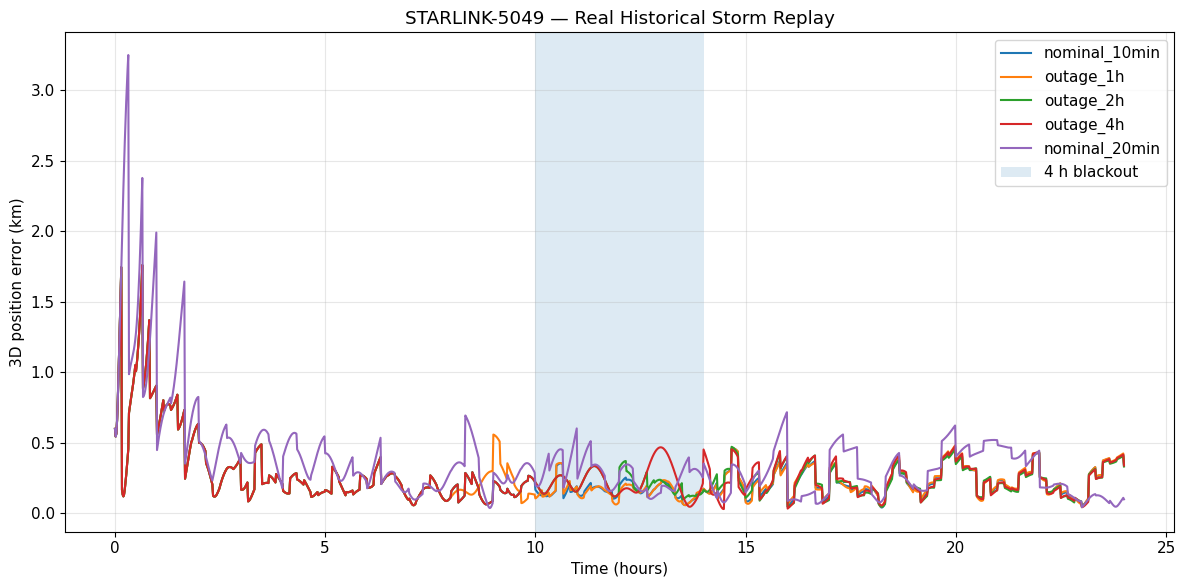

✅ Saved: /content/IAC2026_FINAL_WEEK1B/outputs/real_weather_outage_stress_error.png


In [ ]:
# G1 — Plot real-weather outage tracking error

plt.figure(
    figsize=(12, 6)
)

for schedule_name, content in (
    stress_filters.items()
):

    plt.plot(
        DYN_TIME_HR,
        content[
            "error"
        ],
        label=schedule_name,
    )


for start_hr, end_hr in (
    OUTAGE_SCHEDULES[
        "outage_4h"
    ][
        "outages_hr"
    ]
):

    plt.axvspan(
        start_hr,
        end_hr,
        alpha=0.15,
        label="4 h blackout",
    )


plt.xlabel(
    "Time (hours)"
)

plt.ylabel(
    "3D position error (km)"
)

plt.title(
    f"{stress_row['OBJECT_NAME']} — "
    "Real Historical Storm Replay"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

STRESS_PLOT = (
    OUTPUT_DIR
    / "real_weather_outage_stress_error.png"
)

plt.savefig(
    STRESS_PLOT,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "✅ Saved:",
    STRESS_PLOT,
)

# ✅ WEEK-1B STOP POINT

If the notebook reaches this point successfully, we have replaced the artificial disturbance with a real-weather / physical-drag framework.

Before generating the large GRU training set, inspect:

1. corrected 18/6/6 split;
2. selected real quiet/moderate/storm dates;
3. observed F10.7/Ap profiles;
4. NRLMSISE-00 density differences;
5. physical 24-hour trajectory divergence across several TRAIN objects;
6. newly selected EKF process noise;
7. real-storm outage behavior.

## Still intentionally not done

- no TEST object tracking;
- no GRU;
- no RF;
- no architecture tuning.

The next notebook will scale this frozen physical framework into the ML training/validation dataset.

In [ ]:
# H0 — Reproducibility manifest

manifest = {
    "created_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "source_week1_bundle": (
        EXPECTED_ZIP.name
    ),
    "cohort_file": (
        CORRECTED_COHORT_PATH.name
    ),
    "object_split": {
        "TRAIN": int(
            (
                cohort_df[
                    "SPLIT"
                ]
                == "TRAIN"
            ).sum()
        ),
        "VALIDATION": int(
            (
                cohort_df[
                    "SPLIT"
                ]
                == "VALIDATION"
            ).sum()
        ),
        "TEST": int(
            (
                cohort_df[
                    "SPLIT"
                ]
                == "TEST"
            ).sum()
        ),
    },
    "test_shells": sorted(
        list(
            set(
                cohort_df.loc[
                    cohort_df[
                        "SPLIT"
                    ]
                    == "TEST",
                    "SHELL",
                ]
            )
        )
    ),
    "historical_replay_window": {
        k: str(v)
        for k, v
        in REAL_EVENT_DAYS.items()
    },
    "atmosphere_model": (
        "NRLMSISE-00 via pymsis"
    ),
    "space_weather_inputs": (
        "historical F10.7 and Ap via pymsis/CelesTrak"
    ),
    "drag_coefficient": (
        DRAG_COEFFICIENT
    ),
    "area_to_mass_m2_kg": (
        AREA_TO_MASS_M2_KG
    ),
    "dynamics_dt_seconds": (
        DYN_DT
    ),
    "duration_hours": (
        DYN_HOURS
    ),
    "selected_sigma_a_km_s2": (
        SIGMA_A_WEEK1B
    ),
    "measurement_sigma_km": (
        R_STD
    ),
    "test_objects_used_for_tracking": False,
    "scientific_note": (
        "Historical forcing replay: current frozen "
        "Starlink orbital initial conditions are exposed "
        "to observed historical space-weather conditions; "
        "this is not an exact reconstruction of the 2022 "
        "Starlink trajectories."
    ),
}

MANIFEST_PATH = (
    ROOT_DIR
    / "week1b_reproducibility_manifest.json"
)

with open(
    MANIFEST_PATH,
    "w",
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
    )


print(
    "✅ Week-1b reproducibility manifest saved"
)

print(
    "   ",
    MANIFEST_PATH,
)

✅ Week-1b reproducibility manifest saved
    /content/IAC2026_FINAL_WEEK1B/week1b_reproducibility_manifest.json


In [ ]:
# H1 — List saved Week-1b outputs

print(
    "Week-1b saved files:"
)

for path in sorted(
    ROOT_DIR.rglob("*")
):

    if path.is_file():

        print(
            "  -",
            path.relative_to(
                ROOT_DIR
            ),
        )

Week-1b saved files:
  - data/real_space_weather_daily_activity_scan.csv
  - data/starlink_30_object_cohort_WEEK1B.csv
  - outputs/real_MSIS_density_demo.png
  - outputs/real_MSIS_density_summary.csv
  - outputs/real_historical_F107_Ap_profiles.png
  - outputs/real_weather_Q_calibration.png
  - outputs/real_weather_Q_sweep_TRAIN.csv
  - outputs/real_weather_Q_sweep_VALIDATION.csv
  - outputs/real_weather_multiobject_divergence.csv
  - outputs/real_weather_multiobject_divergence.png
  - outputs/real_weather_outage_stress_error.png
  - outputs/real_weather_outage_stress_summary.csv
  - outputs/week1b_corrected_object_split.png
  - week1_source/data/starlink_30_object_cohort.csv
  - week1_source/data/starlink_supgp_snapshot.json
  - week1_source/data/starlink_supgp_snapshot_metadata.json
  - week1_source/outputs/cohort_RAAN_vs_inclination.png
  - week1_source/outputs/cohort_short_propagation_sanity.csv
  - week1_source/outputs/demo_24h_environment_and_mismatch.png
  - week1_source/outputs

# Optional — Download Week-1b bundle

Set `DOWNLOAD_WEEK1B_BUNDLE = True` and run the final cell once.

Also download the executed `.ipynb` from Colab after the run.

In [ ]:
# H2 — OPTIONAL archive/download

DOWNLOAD_WEEK1B_BUNDLE = True

if DOWNLOAD_WEEK1B_BUNDLE:

    archive_base = (
        "/content/"
        "IAC2026_FINAL_WEEK1B_bundle"
    )

    shutil.make_archive(
        archive_base,
        "zip",
        ROOT_DIR,
    )

    archive_path = (
        archive_base
        + ".zip"
    )

    print(
        "✅ Archive created:",
        archive_path,
    )

    from google.colab import files

    files.download(
        archive_path
    )

else:

    print(
        "DOWNLOAD_WEEK1B_BUNDLE is False."
    )

    print(
        "Change it to True after "
        "the notebook finishes successfully."
    )

✅ Archive created: /content/IAC2026_FINAL_WEEK1B_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>